# Aura Graph RAG 품질·중심성 분석 리포트

AuraDB에 적재된 `ArxivPaper` 그래프를 대상으로 **준수율 · 정밀도 · ER 일관성** 세 수치를 재고,
같은 리포트에 **GDS PageRank 허브 10**과 **커뮤니티 5**를 실어 그래프의 중심이 무엇인지 숫자로 말합니다.

| 지표 | 측정 대상 | 정의 |
|---|---|---|
| **준수율** | Aura 그래프 | 스키마 규칙(식별자 형식·필수 속성·분류 정합·날짜·임베딩 차원·저자 연결)을 모두 통과한 노드와, 라벨/자기참조 규칙을 통과한 관계의 비율 |
| **정밀도** | Aura 그래프 ↔ 원천 JSONL | 고정 시드로 뽑은 무작위 50건에 대해 *논문 존재 · 제목 · 주분류 · 분류집합 · 저자 · 참고관계* 6개 사실을 채점한 일치율 |
| **ER 일관성** | Aura 그래프 | 중복 ID·필수값 누락·고아 노드·타입 오류 관계 등 불변식 6종 중 위반이 없는 비율 |
| **PageRank 허브 10** | GDS | PageRank 점수 상위 10개 노드 |
| **커뮤니티 5** | GDS | Louvain 커뮤니티 상위 5개의 크기·구성과 **각 커뮤니티의 PageRank 대표 노드** |

**참고관계 방향** — 원천 JSONL의 `cit_arxiv_id`는 *그 논문을 인용한* 논문 목록입니다.
따라서 그래프의 올바른 방향은 `(cit_arxiv_id 논문)-[:REFERENCES]->(해당 논문)`이고,
정밀도는 표본 논문의 **들어오는** REFERENCES와 대조합니다.

Aura에는 아무것도 쓰지 않습니다. GDS 계산은 임시 Aura Graph Analytics 세션에서 수행하고 마지막 셀에서 삭제합니다.

In [1]:
from __future__ import annotations

import json, math, os, random, re, warnings
from collections import Counter
from datetime import datetime, timedelta
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
AI_DIR = ROOT / 'data' / 'ai'
REFERENCE_DIR = ROOT / 'data' / 'ai_references' / 'arxiv_ai_references_api'
if not REFERENCE_DIR.exists() and (ROOT / 'data' / 'ai_references_api').exists():
    REFERENCE_DIR = ROOT / 'data' / 'ai_references_api'
REPORT_DIR = ROOT / 'reports'

SAMPLE_SIZE = 50
RANDOM_SEED = 20260917
PAPER_LABEL = 'ArxivPaper'
AUTHOR_LABEL = 'ArxivAuthorName'
TOP_HUBS = 10
TOP_COMMUNITIES = 5

NEW_ID = re.compile(r'(?:(?:https?://)?(?:www\.)?arxiv\.org/(?:abs|pdf)/|arxiv:)?([0-9]{4}\.[0-9]{4,5})(?:v[0-9]+)?(?:\.pdf)?$', re.I)
OLD_ID = re.compile(r'(?:(?:https?://)?(?:www\.)?arxiv\.org/(?:abs|pdf)/|arxiv:)?([a-z-]+(?:\.[A-Z]{2})?/\d{7})(?:v[0-9]+)?(?:\.pdf)?$', re.I)
# Cypher `=~`는 전체 일치이며, 위 정규화가 뱉는 표준형과 같은 문법을 검사합니다.
ARXIV_ID_CYPHER = r'[0-9]{4}\.[0-9]{4,5}|[a-z-]+(\.[A-Z]{2})?/[0-9]{7}'

def normalize_arxiv_id(value):
    if value is None: return None
    text = str(value).strip()
    for pattern in (NEW_ID, OLD_ID):
        m = pattern.fullmatch(text)
        if m: return m.group(1)
    return None

def read_jsonl(path):
    rows = []
    with path.open(encoding='utf-8-sig') as f:
        for line_no, line in enumerate(f, 1):
            if line.strip(): rows.append((line_no, json.loads(line)))
    return rows

def pct(x):
    return '측정불가' if x is None or (isinstance(x, float) and math.isnan(x)) else f'{x:.4f}'

## 1. Aura 연결 및 그래프 스냅샷
`.env`는 출력하지 않고, 자격증명은 환경변수에서만 읽습니다.

In [2]:
from dotenv import load_dotenv
load_dotenv(ROOT / '.env'); load_dotenv(ROOT / 'notebooks' / '.env')
try:
    from neo4j import GraphDatabase
except ImportError as exc:
    raise ImportError('실행 환경에 neo4j와 python-dotenv를 설치하세요.') from exc

NEO4J_URI = os.environ['NEO4J_URI']
NEO4J_USER = os.environ.get('NEO4J_USERNAME', os.environ.get('NEO4J_USER'))
NEO4J_PASSWORD = os.environ['NEO4J_PASSWORD']
NEO4J_DATABASE = os.environ.get('NEO4J_DATABASE', 'neo4j')
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD), notifications_min_severity='OFF')
driver.verify_connectivity()

def query(cypher, **params):
    records, _, _ = driver.execute_query(cypher, parameters_=params, database_=NEO4J_DATABASE)
    return [r.data() for r in records]

node_counts = query('MATCH (n) WITH labels(n) AS labels, count(*) AS n RETURN labels, n ORDER BY n DESC')
rel_counts = query('MATCH ()-[r]->() RETURN type(r) AS relationship, count(r) AS n ORDER BY n DESC')
print('노드 라벨별:', node_counts)
print('관계별:', rel_counts)

노드 라벨별: [{'labels': ['ArxivAuthorName'], 'n': 111171}, {'labels': ['ArxivPaper'], 'n': 37854}]
관계별: [{'relationship': 'AUTHORED', 'n': 268928}, {'relationship': 'REFERENCES', 'n': 69438}]


## 2. 준수율 — Aura 그래프가 스키마 규칙을 지키는 비율
노드 규칙 8종과 관계 규칙 2종을 Cypher로 직접 검사합니다. 규칙 이름과 검사식은 한 리스트에서 생성되므로 서로 어긋날 수 없습니다.

In [3]:
# 규칙 이름과 Cypher 검사식을 한 곳에서 정의합니다.
NODE_RULES = [
    ('arxiv_id 형식',      "p.arxiv_id IS NOT NULL AND p.arxiv_id =~ $id_re"),
    ('title 존재',          "p.title IS NOT NULL AND trim(p.title) <> ''"),
    ('abstract 존재',       "p.abstract IS NOT NULL AND trim(p.abstract) <> ''"),
    ('primary_category 정합', "p.primary_category IS NOT NULL AND p.primary_category IN p.categories"),
    ('categories 비어있지 않음', "p.categories IS NOT NULL AND size(p.categories) > 0"),
    ('published 유효',      "p.published IS NOT NULL AND p.published <= datetime()"),
    ('embedding 차원 일치',  "p.embedding IS NOT NULL AND size(p.embedding) = p.embedding_dimensions"),
    ('저자 연결 존재',       f"EXISTS {{ (:{AUTHOR_LABEL})-[:AUTHORED]->(p) }}"),
]
_flags = ',\n  '.join(f'({expr}) AS r{i}' for i, (_, expr) in enumerate(NODE_RULES))
_sums  = ',\n  '.join(f'sum(CASE WHEN r{i} THEN 1 ELSE 0 END) AS c{i}' for i in range(len(NODE_RULES)))
_all   = ' AND '.join(f'r{i}' for i in range(len(NODE_RULES)))
node_stat = query(f'''
MATCH (p:{PAPER_LABEL})
WITH p,
  {_flags}
RETURN count(*) AS total,
  {_sums},
  sum(CASE WHEN {_all} THEN 1 ELSE 0 END) AS all_ok
''', id_re=ARXIV_ID_CYPHER)[0]

rel_stat = query(f'''
CALL {{
  MATCH (s)-[r:REFERENCES]->(t)
  RETURN count(r) AS total, sum(CASE WHEN s:{PAPER_LABEL} AND t:{PAPER_LABEL} AND s <> t THEN 1 ELSE 0 END) AS ok
}}
WITH total AS ref_total, ok AS ref_ok
CALL {{
  MATCH (s)-[r:AUTHORED]->(t)
  RETURN count(r) AS total, sum(CASE WHEN s:{AUTHOR_LABEL} AND t:{PAPER_LABEL} THEN 1 ELSE 0 END) AS ok
}}
RETURN ref_total, ref_ok, total AS auth_total, ok AS auth_ok
''')[0]

node_rule_rates = {name: (node_stat[f'c{i}'] / node_stat['total'] if node_stat['total'] else float('nan'))
                   for i, (name, _) in enumerate(NODE_RULES)}
checked = node_stat['total'] + rel_stat['ref_total'] + rel_stat['auth_total']
passed = node_stat['all_ok'] + rel_stat['ref_ok'] + rel_stat['auth_ok']
compliance = {
    'nodes': node_stat['all_ok'] / node_stat['total'] if node_stat['total'] else float('nan'),
    'references': rel_stat['ref_ok'] / rel_stat['ref_total'] if rel_stat['ref_total'] else float('nan'),
    'authored': rel_stat['auth_ok'] / rel_stat['auth_total'] if rel_stat['auth_total'] else float('nan'),
    'overall': passed / checked if checked else float('nan'),
}
print(f"검사 대상: 논문 노드 {node_stat['total']:,} · REFERENCES {rel_stat['ref_total']:,} · AUTHORED {rel_stat['auth_total']:,}")
print('규칙별 통과율:')
for name, rate in node_rule_rates.items():
    flag = '' if rate == 1.0 else f"   ← 위반 {node_stat['total'] - round(rate * node_stat['total']):,}건"
    print(f'  - {name:22s} {rate:.4f}{flag}')
print('준수율:', {k: pct(v) for k, v in compliance.items()})

검사 대상: 논문 노드 37,854 · REFERENCES 69,438 · AUTHORED 268,928
규칙별 통과율:
  - arxiv_id 형식            1.0000
  - title 존재               1.0000
  - abstract 존재            1.0000
  - primary_category 정합    1.0000
  - categories 비어있지 않음     1.0000
  - published 유효           1.0000
  - embedding 차원 일치        1.0000
  - 저자 연결 존재               1.0000
준수율: {'nodes': '1.0000', 'references': '1.0000', 'authored': '1.0000', 'overall': '1.0000'}


## 3. 정밀도 — 무작위 50건을 원천 JSONL 기준으로 채점
표본은 고정 시드로 뽑고, 논문 1건마다 6개 사실을 채점합니다.
`참고관계`는 원천에 `cit_arxiv_id` 필드가 있는 레코드에서만 채점하므로 분모가 사실마다 다릅니다.

In [4]:
ai_files = sorted(AI_DIR.glob('*.jsonl')) if AI_DIR.exists() else []
# metadata_cache는 논문 레코드가 아니라 API 캐시라 검사 대상에서 뺍니다.
ref_files = [p for p in sorted(REFERENCE_DIR.glob('*.jsonl')) if 'metadata_cache' not in p.name] if REFERENCE_DIR.exists() else []
if not ai_files and not ref_files:
    raise FileNotFoundError('data/ai 또는 data/ai_references/arxiv_ai_references_api에 JSONL이 없습니다.')

source_by_id, unparsable_ids, source_row_count = {}, 0, 0
for path in ai_files + ref_files:
    for _, row in read_jsonl(path):
        source_row_count += 1
        rid = normalize_arxiv_id(row.get('id'))
        if rid is None:
            unparsable_ids += 1
            continue
        source_by_id.setdefault(rid, row)
print(f'원천 파일 {len(ai_files) + len(ref_files)}개 · 레코드 {source_row_count:,}건 · 고유 논문 {len(source_by_id):,}건 · ID 파싱 실패 {unparsable_ids:,}건')

rng = random.Random(RANDOM_SEED)
candidates = sorted(source_by_id)          # 정렬로 파일 순서에 의존하지 않게 고정
rng.shuffle(candidates)
ids = candidates[:min(SAMPLE_SIZE, len(candidates))]
if len(ids) < SAMPLE_SIZE:
    warnings.warn(f'유효한 고유 논문이 {len(ids)}건뿐입니다. 50건 미만 표본으로 계산합니다.')

aura_rows = query(f'''
UNWIND $ids AS id
OPTIONAL MATCH (p:{PAPER_LABEL} {{arxiv_id: id}})
RETURN id,
       p IS NOT NULL AS exists,
       p.title AS title,
       p.primary_category AS primary_category,
       p.categories AS categories,
       [(p)<-[:AUTHORED]-(a:{AUTHOR_LABEL}) | a.name] AS authors,
       [(p)<-[:REFERENCES]-(c:{PAPER_LABEL}) | c.arxiv_id] AS citing
''', ids=ids)
aura_by_id = {r['id']: r for r in aura_rows}

FACTS = ['paper_exists', 'title', 'primary_category', 'categories', 'authors', 'references']
scored = Counter(); passed_facts = Counter(); detail = []
for rid in ids:
    row, g = source_by_id[rid], aura_by_id.get(rid, {})
    exists = bool(g.get('exists'))
    facts = {
        'paper_exists': exists,
        'title': exists and str(g.get('title') or '').strip() == str(row.get('title') or '').strip(),
        'primary_category': exists and g.get('primary_category') == row.get('primary_category'),
        'categories': exists and set(g.get('categories') or []) >= set(row.get('categories') or []),
        'authors': exists and set(row.get('authors') or []) <= set(g.get('authors') or []),
    }
    # cit_arxiv_id = "이 논문을 인용한 논문" → 그래프에서는 들어오는 REFERENCES와 대조합니다.
    if 'cit_arxiv_id' in row:
        want = {normalize_arxiv_id(c) for c in (row.get('cit_arxiv_id') or [])} - {None, rid}
        facts['references'] = exists and want <= set(g.get('citing') or [])
    for k, v in facts.items():
        scored[k] += 1; passed_facts[k] += bool(v)
    detail.append({'arxiv_id': rid, **facts})

total_scored = sum(scored.values()); total_passed = sum(passed_facts.values())
precision = total_passed / total_scored if total_scored else float('nan')
fact_precision = {k: (passed_facts[k] / scored[k] if scored[k] else None) for k in FACTS}
print(f'표본 {len(ids)}건 · 시드 {RANDOM_SEED}')
print(f'정밀도: {total_passed}/{total_scored} = {pct(precision)}')
for k in FACTS:
    print(f'  - {k:17s} {passed_facts[k]:3d}/{scored[k]:3d}  {pct(fact_precision[k])}')
failed = [d for d in detail if not all(v for kk, v in d.items() if kk != 'arxiv_id')]
print('불일치 레코드:', [d['arxiv_id'] for d in failed] or '없음')

원천 파일 9개 · 레코드 38,380건 · 고유 논문 37,854건 · ID 파싱 실패 0건


표본 50건 · 시드 20260917
정밀도: 289/289 = 1.0000
  - paper_exists       50/ 50  1.0000
  - title              50/ 50  1.0000
  - primary_category   50/ 50  1.0000
  - categories         50/ 50  1.0000
  - authors            50/ 50  1.0000
  - references         39/ 39  1.0000
불일치 레코드: 없음


## 4. ER 일관성 — 그래프 불변식 검사

In [5]:
er_checks = query(f'''
CALL {{ MATCH (p:{PAPER_LABEL}) WHERE p.arxiv_id IS NULL OR p.arxiv_id = '' RETURN count(*) AS n }}
WITH n AS missing_id
CALL {{ MATCH (p:{PAPER_LABEL}) WHERE p.title IS NULL OR trim(p.title) = '' RETURN count(*) AS n }}
WITH missing_id, n AS missing_title
CALL {{ MATCH (a)-[r:AUTHORED]->(p) WHERE NOT a:{AUTHOR_LABEL} OR NOT p:{PAPER_LABEL} RETURN count(*) AS n }}
WITH missing_id, missing_title, n AS authored_type_error
CALL {{ MATCH (p)-[r:REFERENCES]->(q) WHERE NOT p:{PAPER_LABEL} OR NOT q:{PAPER_LABEL} RETURN count(*) AS n }}
WITH missing_id, missing_title, authored_type_error, n AS references_type_error
CALL {{ MATCH (p:{PAPER_LABEL}) WHERE NOT (p)<-[:AUTHORED]-(:{AUTHOR_LABEL}) RETURN count(*) AS n }}
RETURN missing_id, missing_title, authored_type_error, references_type_error, n AS orphan_papers
''')
# Neo4j 제약조건이 없거나 중복이 남은 경우도 별도 검사합니다.
duplicate_ids = query(f'''MATCH (p:{PAPER_LABEL}) WHERE p.arxiv_id IS NOT NULL
WITH p.arxiv_id AS id, count(*) AS n WHERE n > 1 RETURN sum(n-1) AS n''')[0]['n'] or 0
er = er_checks[0] if er_checks else {}
violations = {'missing_id': er.get('missing_id', 0), 'duplicate_id': duplicate_ids,
              'missing_title': er.get('missing_title', 0), 'authored_type_error': er.get('authored_type_error', 0),
              'references_type_error': er.get('references_type_error', 0), 'orphan_papers': er.get('orphan_papers', 0)}
er_score = 1.0 - sum(bool(v) for v in violations.values()) / len(violations)
print('ER 검사 위반 건수:', violations)
print(f'ER 일관성 점수(위반 항목 6종 기준): {er_score:.4f}')

ER 검사 위반 건수: {'missing_id': 0, 'duplicate_id': 0, 'missing_title': 0, 'authored_type_error': 0, 'references_type_error': 0, 'orphan_papers': 0}
ER 일관성 점수(위반 항목 6종 기준): 1.0000


## 5. GDS PageRank 허브 10 · 커뮤니티 5
AuraDB Free는 GDS를 내장하지 않으므로 임시 **Aura Graph Analytics 세션**(2GB, 30분)에서 계산합니다.
원본 AuraDB에는 쓰지 않으며, 세션은 마지막 셀에서 삭제합니다.
GDS를 못 쓰는 환경이면 경고만 남기고 앞의 품질 지표는 그대로 보존합니다.

> **재현성** — 준수율·정밀도·ER 일관성과 PageRank는 실행마다 같은 값이 나옵니다.
> 반면 Louvain은 이 세션이 `randomSeed`를 받지 않아 **실행할 때마다 커뮤니티 번호와 크기가 달라집니다.**
> 상위 5개 커뮤니티의 구성과 대표 논문은 대체로 안정적이지만, 숫자를 인용할 때는 이 리포트의 실행 시각을 함께 적으세요.

In [6]:
import uuid
import pandas as pd
try:
    from graphdatascience.session import GdsSessions, AuraAPICredentials, DbmsConnectionInfo, SessionMemory
except ImportError as exc:
    raise ImportError('uv sync 또는 pip install graphdatascience>=1.18 후 커널을 재시작하세요.') from exc

CLIENT_ID = os.environ.get('CLIENT_ID')
CLIENT_SECRET = os.environ.get('CLIENT_SECRET')
PROJECT_ID = os.environ.get('PROJECT_ID')
if not CLIENT_ID or not CLIENT_SECRET:
    raise RuntimeError('`.env`에 CLIENT_ID와 CLIENT_SECRET을 설정하세요.')

GDS_SESSION_NAME = f'aura_quality_{uuid.uuid4().hex[:10]}'
gds = None
pagerank_top10, community_top5, community_rows, community_panels = [], [], [], []
flow_matrix, louvain_mode = None, None

def _node_meta(node_ids):
    # GDS nodeId(= AuraDB 내부 id)로 노드 메타데이터를 되읽습니다.
    rows = query(f'''UNWIND $ids AS nid MATCH (n) WHERE id(n) = nid
    RETURN id(n) AS nodeId, labels(n)[0] AS label,
           coalesce(n.arxiv_id, n.name) AS key, n.title AS title''', ids=[int(x) for x in node_ids])
    return {int(r['nodeId']): r for r in rows}

try:
    sessions = GdsSessions(api_credentials=AuraAPICredentials(CLIENT_ID, CLIENT_SECRET, PROJECT_ID))
    gds = sessions.get_or_create(session_name=GDS_SESSION_NAME, memory=SessionMemory.m_2GB,
                                 ttl=timedelta(minutes=30), db_connection=DbmsConnectionInfo.from_env(), timeout=600)
    gds.verify_connectivity()
    # PageRank/Louvain에는 숫자 속성이 필요 없으므로 문자열 속성은 프로젝션하지 않습니다.
    G, project_result = gds.v2.graph.project_native(GDS_SESSION_NAME, [PAPER_LABEL, AUTHOR_LABEL],
                                                    ['AUTHORED', 'REFERENCES'])
    print('Aura Graph Analytics 원격 프로젝션:', project_result)

    pagerank = gds.pageRank.stream(G, maxIterations=20, dampingFactor=0.85)
    # randomSeed를 받아주면 재현 가능한 커뮤니티를 얻고, 아니면(현재 Aura Graph Analytics 세션이
    # 그렇습니다) 기본 설정으로 돌립니다. 후자는 실행마다 번호·크기가 달라집니다.
    try:
        louvain = gds.louvain.stream(G, randomSeed=RANDOM_SEED, concurrency=1)
        louvain_mode = f'결정적 (randomSeed={RANDOM_SEED}, concurrency=1)'
    except Exception as exc:
        louvain = gds.louvain.stream(G)
        louvain_mode = f'기본 설정 — 실행마다 커뮤니티 번호·크기가 달라집니다 (randomSeed 미지원: {type(exc).__name__})'
    print('Louvain 실행 모드:', louvain_mode)

    nodes = pagerank[['nodeId', 'score']].merge(louvain[['nodeId', 'communityId']], on='nodeId')
    nodes['nodeId'] = nodes['nodeId'].astype(int)

    # --- PageRank 허브 10 ---
    hubs = nodes.sort_values('score', ascending=False).head(TOP_HUBS)
    meta = _node_meta(hubs['nodeId'])
    pagerank_top10 = [{**meta.get(int(r.nodeId), {'nodeId': int(r.nodeId)}),
                       'communityId': int(r.communityId), 'score': float(r.score)}
                      for r in hubs.itertuples()]

    # --- 커뮤니티 5: 크기·구성·PageRank 대표 노드 ---
    sizes = nodes.groupby('communityId').size().sort_values(ascending=False).head(TOP_COMMUNITIES)
    top_ids = sizes.index.tolist()
    label_of = {cid: f'C{i + 1}' for i, cid in enumerate(top_ids)}
    members = nodes[nodes.communityId.isin(top_ids)]

    # 커뮤니티별 상위 PageRank 후보만 되읽어 대표 논문을 고릅니다(저자 노드는 제외).
    probe = members.sort_values('score', ascending=False).groupby('communityId').head(60)
    probe_meta = _node_meta(probe['nodeId'])
    # 구성(논문/저자)은 전체 멤버를 대상으로 세어야 하므로 따로 질의합니다.
    composition = pd.DataFrame(query('''UNWIND $ids AS nid MATCH (n) WHERE id(n) = nid
    RETURN id(n) AS nodeId, labels(n)[0] AS label''', ids=members['nodeId'].tolist()))
    composition['nodeId'] = composition['nodeId'].astype(int)
    composition = composition.merge(members, on='nodeId')
    counts = composition.groupby(['communityId', 'label']).size().unstack(fill_value=0)

    for cid in top_ids:
        ranked = probe[probe.communityId == cid].sort_values('score', ascending=False)
        papers = [{'arxiv_id': probe_meta[int(r.nodeId)]['key'],
                   'title': probe_meta[int(r.nodeId)]['title'], 'score': float(r.score)}
                  for r in ranked.itertuples() if probe_meta.get(int(r.nodeId), {}).get('label') == PAPER_LABEL]
        rep = papers[0] if papers else None
        community_top5.append({'label': label_of[cid], 'communityId': int(cid), 'size': int(sizes[cid]),
                               'papers': int(counts.loc[cid].get(PAPER_LABEL, 0)),
                               'authors': int(counts.loc[cid].get(AUTHOR_LABEL, 0)),
                               'representative': rep})
        community_rows.append({'label': label_of[cid], 'size': int(sizes[cid]),
                               'papers': int(counts.loc[cid].get(PAPER_LABEL, 0)),
                               'authors': int(counts.loc[cid].get(AUTHOR_LABEL, 0)),
                               'hub_title': (rep or {}).get('title', '(대표 논문 없음)')})
        community_panels.append({'label': label_of[cid], 'size': int(sizes[cid]), 'papers': papers[:4]})

    # --- 커뮤니티 간 인용 흐름 ---
    community_of = dict(zip(nodes.nodeId, nodes.communityId))
    names = [label_of[c] for c in top_ids] + ['기타']
    flow_matrix = pd.DataFrame(0, index=names, columns=names)
    for e in query(f'MATCH (s:{PAPER_LABEL})-[:REFERENCES]->(t:{PAPER_LABEL}) RETURN id(s) AS s, id(t) AS t'):
        flow_matrix.loc[label_of.get(community_of.get(e['s']), '기타'),
                        label_of.get(community_of.get(e['t']), '기타')] += 1

    print(f'\nPageRank 허브 {TOP_HUBS}')
    for h in pagerank_top10:
        print(f"  {h['score']:8.2f}  {h.get('key')}  {str(h.get('title'))[:64]}")
    print(f'\n커뮤니티 {TOP_COMMUNITIES} (전체 {nodes.communityId.nunique():,}개 중)')
    for c in community_top5:
        rep = c['representative'] or {}
        print(f"  {c['label']} id={c['communityId']:<7} 크기 {c['size']:>6,} "
              f"(논문 {c['papers']:,} / 저자 {c['authors']:,})  대표: {str(rep.get('title'))[:52]}")
    print('\n커뮤니티 간 인용 흐름 (행=인용한 쪽, 열=인용된 쪽)')
    print(flow_matrix.to_string())
except Exception as exc:
    warnings.warn(f'GDS 분석을 건너뜁니다: {type(exc).__name__}: {exc}')

C:\Users\Playdata\Desktop\arxiv_graph_RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GraphImportProcess:   0%|          | 0.0/100 [00:00<?, ?%/s]

GraphImportProcess:   0%|          | 0.0/100 [00:00<?, ?%/s, status: NODE_LOADING, task: Node import]

GraphImportProcess:   0%|          | 0.0/100 [00:00<?, ?%/s, status: NODE_LOADING, task: Node import]

GraphImportProcess:   0%|          | 0.0/100 [00:00<?, ?%/s, status: NODE_LOADING, task: Node import]

...

 Louvain: 100%|██████████| 100.0/100 [00:26<00:00,  3.79%/s, status: FINISHED]

 Louvain: 100%|██████████| 100.0/100 [00:26<00:00,  3.79%/s, status: FINISHED]

 Louvain: 100%|██████████| 100.0/100 [00:26<00:00,  3.77%/s, status: FINISHED]

Louvain 실행 모드: 기본 설정 — 실행마다 커뮤니티 번호·크기가 달라집니다 (randomSeed 미지원: ClientError)



PageRank 허브 10
    261.64  2507.06261  Gemini 2.5: Pushing the Frontier with Advanced Reasoning, Multim
    111.22  2501.14249  Humanity's Last Exam
     82.55  2506.12103  The Amazon Nova Family of Models: Technical Report and Model Car
     63.36  2403.05530  Gemini 1.5: Unlocking multimodal understanding across millions o
     58.08  2208.00211  Gaia Data Release 3: Summary of the content and survey propertie
     52.31  2407.21783  The Llama 3 Herd of Models
     36.90  2601.03267  OpenAI GPT-5 System Card
     35.83  2602.04705  ERNIE 5.0 Technical Report
     33.91  0805.2366  LSST: from Science Drivers to Reference Design and Anticipated D
     32.61  2604.16216  A digitally controlled silicon quantum processing unit

커뮤니티 5 (전체 4,942개 중)
  C1 id=74773   크기 18,055 (논문 3,466 / 저자 14,589)  대표: Gemini 2.5: Pushing the Frontier with Advanced Reaso
  C2 id=135535  크기 11,099 (논문 3,143 / 저자 7,956)  대표: Agents' Last Exam
  C3 id=60007   크기  7,956 (논문 1,877 / 저자 6,079)  대표: The Amazon N

## 6. 커뮤니티 시각화
두 장으로 나눕니다.

1. **크기 구성 + 인용 흐름** — 커뮤니티가 얼마나 크고 무엇으로 이루어졌는지, 서로를 얼마나 인용하는지.
2. **커뮤니티별 PageRank 대표 논문** — 각 커뮤니티의 중심이 어떤 논문인지.

색은 한 계열(파랑)을 쓰고 정체성은 축 라벨과 패널 제목이 나릅니다. 커뮤니티마다 PageRank 규모가 100배 넘게
차이 나서 두 번째 그림은 **공유 로그 축 위의 점 그래프**입니다 — 로그 축 위의 막대는 길이 비례가 깨지기 때문입니다.

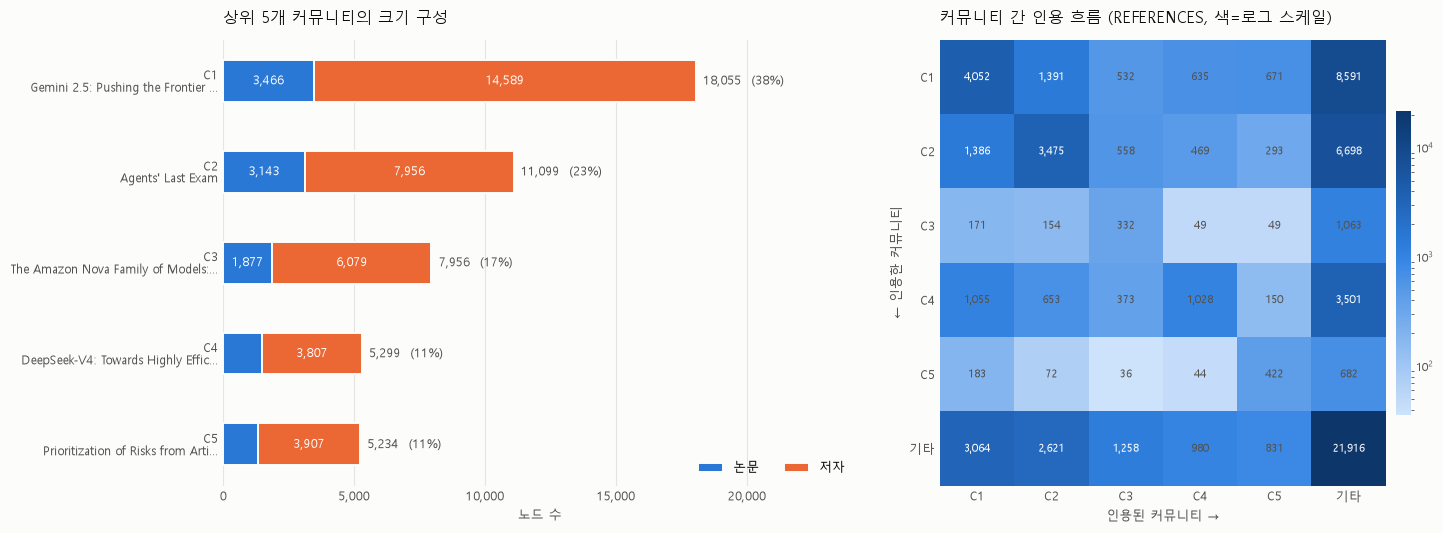

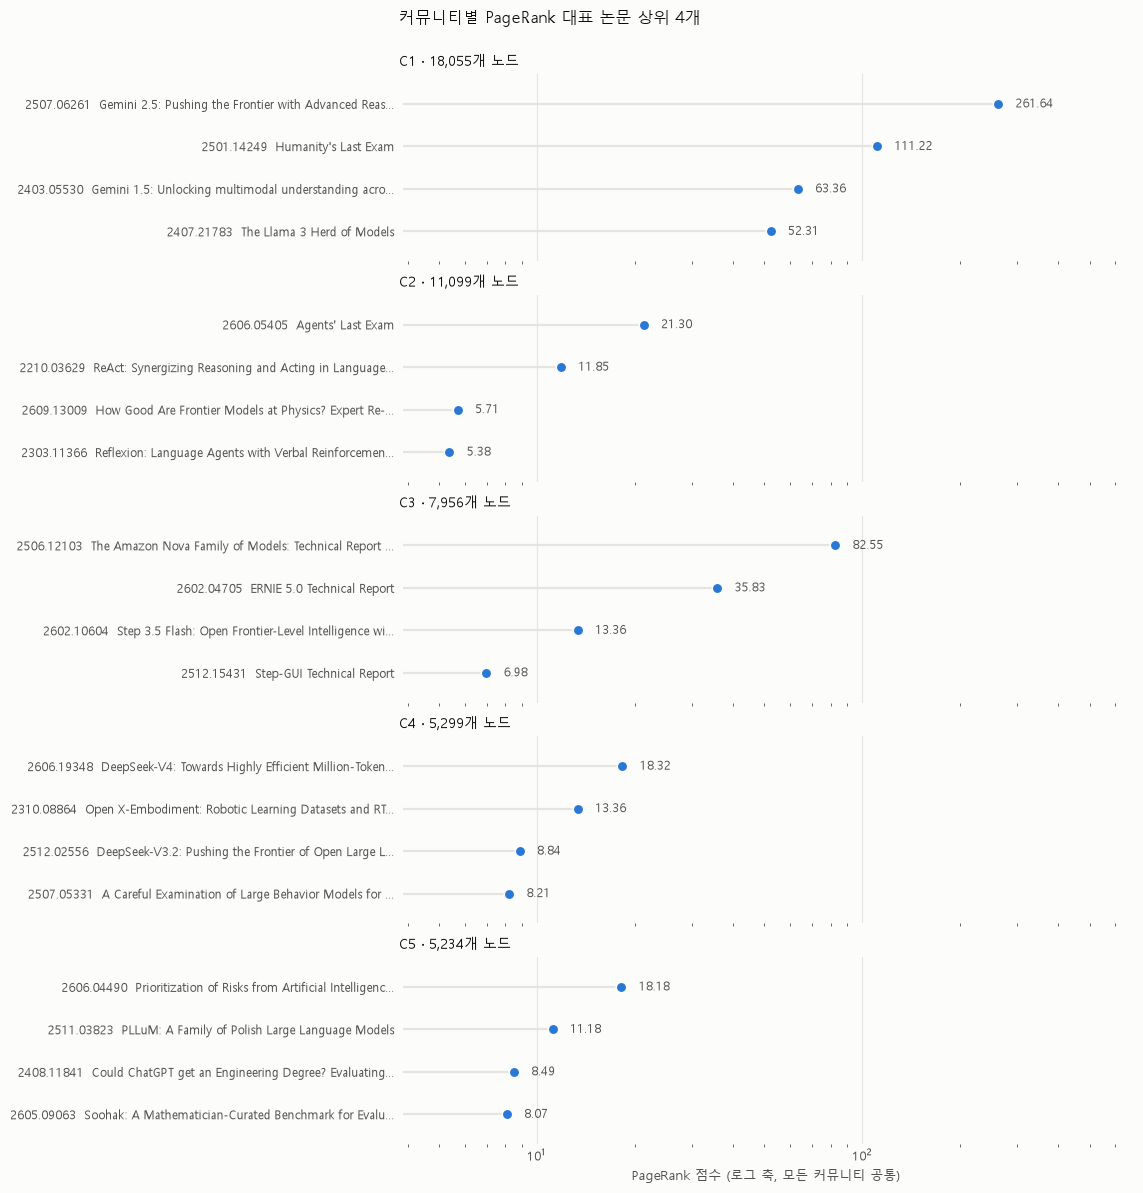

그림 저장:
  C:\Users\Playdata\Desktop\arxiv_graph_RAG\reports\aura_community_overview.png
  C:\Users\Playdata\Desktop\arxiv_graph_RAG\reports\aura_community_hubs.png


In [7]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.font_manager import fontManager

# PNG는 노트북 테마와 무관하게 읽혀야 하므로 라이트 서피스로 고정합니다.
VIZ = {'surface': '#fcfcfb', 'text': '#0b0b0b', 'text2': '#52514e', 'muted': '#8a8985',
       'grid': '#e5e4e0', 's1': '#2a78d6', 's2': '#eb6834'}
BLUES = LinearSegmentedColormap.from_list('aura_blue', [
    '#cde2fb', '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7', '#3987e5',
    '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b'])

_available = {f.name for f in fontManager.ttflist}
for _font in ('Malgun Gothic', 'Noto Sans KR', 'NanumGothic', 'AppleGothic', 'Gulim'):
    if _font in _available:
        mpl.rcParams['font.family'] = _font
        break
else:
    warnings.warn('한글 폰트를 찾지 못했습니다. 그림의 한글이 깨질 수 있습니다.')
mpl.rcParams.update({'axes.unicode_minus': False, 'figure.facecolor': VIZ['surface'],
                     'axes.facecolor': VIZ['surface'], 'savefig.facecolor': VIZ['surface'],
                     'text.color': VIZ['text'], 'axes.labelcolor': VIZ['text2'],
                     'xtick.color': VIZ['text2'], 'ytick.color': VIZ['text2'], 'font.size': 9})

def _bare(ax):
    for s in ('top', 'right', 'left', 'bottom'): ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    ax.xaxis.grid(True, color=VIZ['grid'], linewidth=0.8)
    ax.set_axisbelow(True)

def _short(s, n=42):
    s = ' '.join(str(s or '').split())
    return s if len(s) <= n else s[:n - 1] + '…'

def plot_community_overview(rows, flow, path):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(14.5, 5.4), gridspec_kw={'width_ratios': [1.25, 1]})
    y = np.arange(len(rows))[::-1]
    papers = np.array([r['papers'] for r in rows], float)
    authors = np.array([r['authors'] for r in rows], float)
    axA.barh(y, papers, height=.46, color=VIZ['s1'], edgecolor=VIZ['surface'], linewidth=1.4, label='논문')
    axA.barh(y, authors, height=.46, left=papers, color=VIZ['s2'], edgecolor=VIZ['surface'],
             linewidth=1.4, label='저자')
    total = float((papers + authors).sum())
    # 가장 긴 막대가 축 끝에서 잘리면 비율이 왜곡됩니다.
    xmax = float((papers + authors).max()) * 1.34
    for yi, p, a in zip(y, papers, authors):
        axA.text(p + a + total * 0.006, yi, f'{int(p + a):,}  ({(p + a) / total:.0%})',
                 va='center', ha='left', fontsize=9, color=VIZ['text2'])
        # 칸 안에 숫자가 다 들어갈 만큼 넓을 때만 적습니다 — 좁은 칸에서는 글자가 잘립니다.
        if p > xmax * 0.062:
            axA.text(p / 2, yi, f'{int(p):,}', va='center', ha='center', fontsize=8.5, color='white')
        if a > xmax * 0.062:
            axA.text(p + a / 2, yi, f'{int(a):,}', va='center', ha='center', fontsize=8.5, color='white')
    axA.set_yticks(y)
    axA.set_yticklabels([f"{r['label']}\n{_short(r['hub_title'], 34)}" for r in rows], fontsize=8.5)
    axA.set_xlim(0, xmax)
    axA.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    axA.set_xlabel('노드 수', fontsize=9)
    axA.set_title(f'상위 {len(rows)}개 커뮤니티의 크기 구성', fontsize=11.5, color=VIZ['text'], pad=12, loc='left')
    axA.legend(frameon=False, ncol=2, loc='lower right', fontsize=9)
    _bare(axA)

    M = flow.values.astype(float)
    im = axB.imshow(np.where(M > 0, M, np.nan), cmap=BLUES,
                    norm=LogNorm(vmin=max(M[M > 0].min(), 1), vmax=M.max()))
    axB.set_xticks(range(len(flow.columns))); axB.set_xticklabels(flow.columns, fontsize=9)
    axB.set_yticks(range(len(flow.index)));   axB.set_yticklabels(flow.index, fontsize=9)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            # 글자색은 셀의 정규화 명도로 정합니다 — 로그 스케일이라 원값 기준은 어긋납니다.
            axB.text(j, i, f'{int(M[i, j]):,}', ha='center', va='center', fontsize=8,
                     color='white' if im.norm(M[i, j]) > 0.55 else VIZ['text2'])
    axB.set_xlabel('인용된 커뮤니티 →', fontsize=9)
    axB.set_ylabel('← 인용한 커뮤니티', fontsize=9)
    axB.set_title('커뮤니티 간 인용 흐름 (REFERENCES, 색=로그 스케일)', fontsize=11.5,
                  color=VIZ['text'], pad=12, loc='left')
    for s in axB.spines.values(): s.set_visible(False)
    axB.tick_params(length=0)
    cb = fig.colorbar(im, ax=axB, fraction=.03, pad=.02, shrink=.82)
    cb.outline.set_visible(False); cb.ax.tick_params(length=0, labelsize=8)
    fig.tight_layout(); fig.savefig(path, dpi=150, bbox_inches='tight')
    return fig

def plot_community_hubs(panels, path, top_n=4):
    panels = [p for p in panels if p['papers']]
    fig, axes = plt.subplots(len(panels), 1, figsize=(11.5, 0.6 * top_n * len(panels)), sharex=True)
    axes = np.atleast_1d(axes)
    values = [q['score'] for p in panels for q in p['papers'][:top_n]]
    lo, hi = min(values), max(values)
    for ax, p in zip(axes, panels):
        items = p['papers'][:top_n]
        y = np.arange(len(items))[::-1]
        xs = [q['score'] for q in items]
        ax.hlines(y, lo * 0.72, xs, color=VIZ['grid'], linewidth=1.6, zorder=1)
        ax.scatter(xs, y, s=58, color=VIZ['s1'], zorder=2, edgecolor=VIZ['surface'], linewidth=1.2)
        for yi, q in zip(y, items):
            ax.text(q['score'] * 1.13, yi, f"{q['score']:.2f}", va='center', ha='left',
                    fontsize=8.5, color=VIZ['text2'])
        ax.set_yticks(y)
        ax.set_yticklabels([f"{q['arxiv_id']}  {_short(q['title'], 52)}" for q in items], fontsize=8.5)
        ax.set_ylim(-0.7, len(items) - 0.3)
        ax.set_xscale('log'); ax.set_xlim(lo * 0.7, hi * 2.6)
        ax.set_title(f"{p['label']} · {p['size']:,}개 노드", fontsize=10, color=VIZ['text'], loc='left', pad=6)
        _bare(ax)
    axes[-1].set_xlabel('PageRank 점수 (로그 축, 모든 커뮤니티 공통)', fontsize=9)
    axes[0].annotate(f'커뮤니티별 PageRank 대표 논문 상위 {top_n}개', xy=(0, 1), xycoords='axes fraction',
                     xytext=(0, 34), textcoords='offset points', fontsize=11.5, color=VIZ['text'], va='bottom')
    fig.tight_layout(); fig.savefig(path, dpi=150, bbox_inches='tight')
    return fig

REPORT_DIR.mkdir(exist_ok=True)
FIG_OVERVIEW = REPORT_DIR / 'aura_community_overview.png'
FIG_HUBS = REPORT_DIR / 'aura_community_hubs.png'
figure_paths = []
if community_rows and flow_matrix is not None:
    plot_community_overview(community_rows, flow_matrix, FIG_OVERVIEW)
    plot_community_hubs(community_panels, FIG_HUBS)
    figure_paths = [str(FIG_OVERVIEW), str(FIG_HUBS)]
    plt.show()
    print('그림 저장:', *figure_paths, sep='\n  ')
else:
    warnings.warn('GDS 결과가 없어 커뮤니티 시각화를 건너뜁니다.')

## 7. 리포트 저장과 정리

In [8]:
report = {
    'generated_at': datetime.now().astimezone().isoformat(timespec='seconds'),
    'source_files': {'ai': [str(p) for p in ai_files], 'references_api': [str(p) for p in ref_files]},
    'metrics': {
        'compliance_rate': compliance,
        'compliance_rules': node_rule_rates,
        'precision': None if math.isnan(precision) else precision,
        'precision_by_fact': fact_precision,
        'precision_sample_size': len(ids),
        'precision_seed': RANDOM_SEED,
        'er_consistency': er_score,
    },
    'er_violations': violations,
    'louvain_mode': louvain_mode,
    'pagerank_top10': pagerank_top10,
    'communities_top5': community_top5,
    'community_citation_flow': (flow_matrix.to_dict() if flow_matrix is not None else None),
    'figures': figure_paths,
}
REPORT_DIR.mkdir(exist_ok=True)
out_path = REPORT_DIR / 'aura_graph_rag_quality_report.json'
out_path.write_text(json.dumps(report, ensure_ascii=False, indent=2, default=str), encoding='utf-8')

print('=== Aura Graph RAG 품질 리포트 ===')
print(f"준수율(그래프 전체): {pct(compliance['overall'])}   [노드 {pct(compliance['nodes'])} · "
      f"REFERENCES {pct(compliance['references'])} · AUTHORED {pct(compliance['authored'])}]")
print(f'정밀도: {pct(precision)}  ({len(ids)}건 표본 · {total_scored}개 사실 · seed={RANDOM_SEED})')
print(f'ER 일관성: {er_score:.4f}')
print(f'PageRank 허브: {len(pagerank_top10)}개 / 커뮤니티: {len(community_top5)}개 / 그림 {len(figure_paths)}장')
print('JSON 저장:', out_path)

# 임시 GDS 세션만 정리합니다. AuraDB에는 아무것도 쓰지 않았습니다.
if gds is not None:
    gds.delete()
    print('GDS 세션 삭제:', GDS_SESSION_NAME)
driver.close()

=== Aura Graph RAG 품질 리포트 ===
준수율(그래프 전체): 1.0000   [노드 1.0000 · REFERENCES 1.0000 · AUTHORED 1.0000]
정밀도: 1.0000  (50건 표본 · 289개 사실 · seed=20260917)
ER 일관성: 1.0000
PageRank 허브: 10개 / 커뮤니티: 5개 / 그림 2장
JSON 저장: C:\Users\Playdata\Desktop\arxiv_graph_RAG\reports\aura_graph_rag_quality_report.json


GDS 세션 삭제: aura_quality_1b6347b7c9
